# Project 5 - Clustering Techniques
- I think it will be easiest to implement these thechniques one by one in a notebook so that we can work on them individually.
- can turn it into a .py if needed


## Synthetic Data Generation

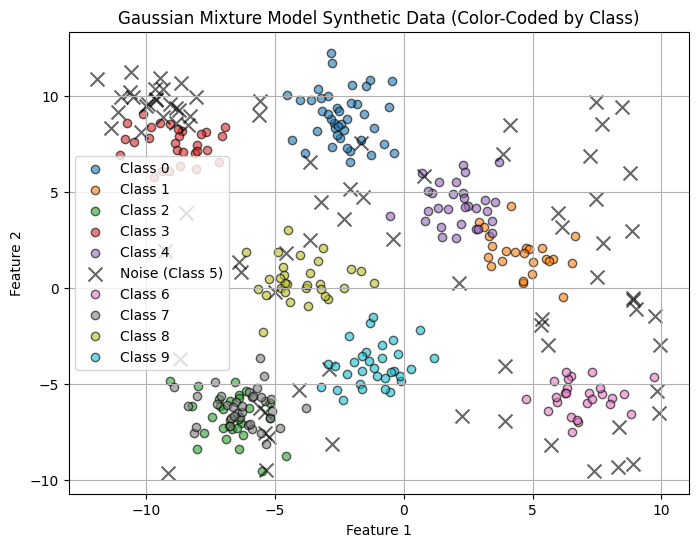

In [122]:
# Gaussian mixture model synthetic data generator
import numpy as np
from torch import seed


def generate_gmm_data_with_noise(n_samples, n_components, n_features, n_noise, seed=42):
    np.random.seed(seed)
    # Generate random means and covariances for the GMM components
    # means between -10 and 10
    means = np.random.rand(n_components, n_features) * 20 - 10


    # Generate random positive semi-definite covariance matrices
    # covariances = np.array([np.dot(np.random.randn(n_features, n_features), 
    #                                np.random.randn(n_features, n_features).T) 
    #                         for _ in range(n_components)])

    # identity covariance matrices
    covariances = np.array([np.eye(n_features) for _ in range(n_components)])

    # Generate samples from the GMM
    samples = []
    labels = []
    for i in range(n_samples):
        component = np.random.choice(n_components)
        sample = np.random.multivariate_normal(means[component], covariances[component])
        samples.append(sample)
        labels.append(component)
    for i in range(n_noise):
        noise = np.random.uniform(low=-10, high=10, size=n_features)
        samples.append(noise)
        labels.append(5)  # Class 5 for noise
    return np.array(samples), np.array(labels)
# Example usage
if __name__ == "__main__":
    n_samples = 300
    n_components = 10
    n_features = 2
    n_noise = n_samples // 5
    data, labels = generate_gmm_data_with_noise(n_samples, n_components, n_features, n_noise)
    # save data and labels to csv
    data_with_labels = np.hstack((data, labels.reshape(-1, 1)))
    np.savetxt(f"{n_components}_components_with_noise.csv", data_with_labels, delimiter=",", header="Feature1,Feature2,Label", comments="")

# visualize
import matplotlib.pyplot as plt
def visualize_data(data, labels, color=True):
    unique_labels = np.unique(labels)
    n_unique = len(unique_labels)
    
    # Generate enough colors for all classes
    if n_unique <= 10:
        colors = plt.cm.tab10(np.arange(n_unique))
    else:
        colors = plt.cm.tab20(np.arange(n_unique))
    
    plt.figure(figsize=(8, 6))
    for idx, class_id in enumerate(unique_labels):
        mask = labels == class_id
        if class_id == 5:  # Noise class
            plt.scatter(data[mask, 0], data[mask, 1], alpha=0.6, label=f'Noise (Class {class_id})', 
                       color='black', marker='x', s=100)
        else:
            plt.scatter(data[mask, 0], data[mask, 1], alpha=0.6, label=f'Class {class_id}', 
                       color=colors[idx], edgecolors='k')
    plt.title("Gaussian Mixture Model Synthetic Data (Color-Coded by Class)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid()
    plt.show()
if __name__ == "__main__":
    visualize_data(data, labels)

## K-Means

## DBSCAN ##


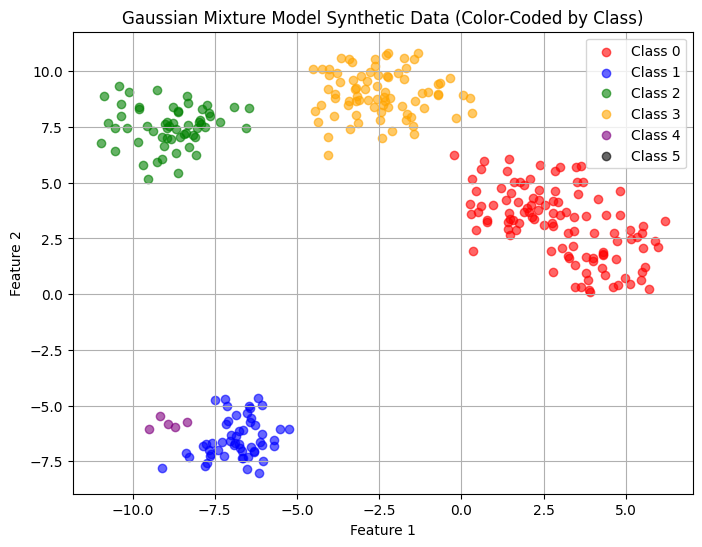

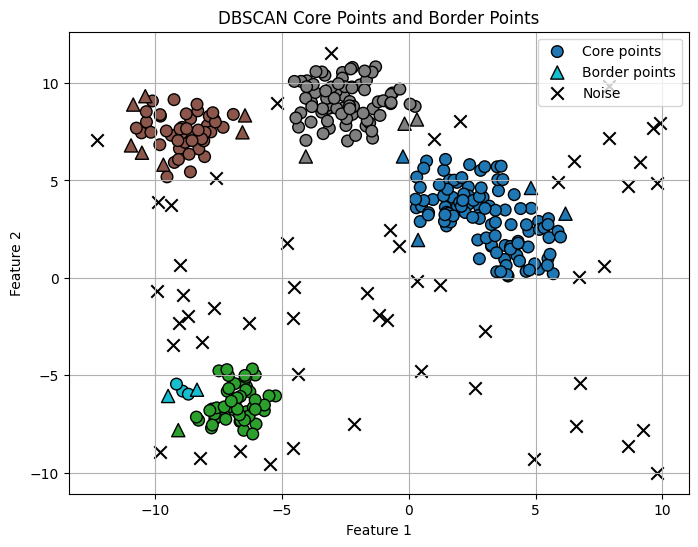

In [116]:
# DBSCAN clustering
from sklearn.cluster import DBSCAN
if __name__ == "__main__":
    # DBSCAN clustering
    dbscan = DBSCAN(eps=1, min_samples=5)
    cluster_labels = dbscan.fit_predict(data)
    visualize_data(data, cluster_labels, color=True)

    # Plot core points and border points in a separate graph
    core_indices = set(dbscan.core_sample_indices_)
    core_mask = np.array([index in core_indices for index in range(len(data))])
    border_mask = (cluster_labels != -1) & ~core_mask
    noise_mask = cluster_labels == -1

    plt.figure(figsize=(8, 6))
    plt.scatter(data[core_mask, 0], data[core_mask, 1], c=cluster_labels[core_mask], cmap="tab10", s=70, marker="o", edgecolors="k", label="Core points")
    plt.scatter(data[border_mask, 0], data[border_mask, 1], c=cluster_labels[border_mask], cmap="tab10", s=90, marker="^", edgecolors="k", label="Border points")
    plt.scatter(data[noise_mask, 0], data[noise_mask, 1], c="black", s=80, marker="x", label="Noise")
    plt.title("DBSCAN Core Points and Border Points")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid()
    plt.show()
# calculate accuracy


In [106]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score, normalized_mutual_info_score

# Treat DBSCAN noise as -1 and compute internal clustering metrics on the non-noise points.
valid_mask = cluster_labels != -1
X_eval = data[valid_mask]
y_eval = cluster_labels[valid_mask]

print(f"Total points: {len(data)}")
print(f"Clustered points: {len(X_eval)}")
print(f"Noise points: {np.sum(~valid_mask)}")
print(f"Clusters found: {len(np.unique(y_eval))}")

if len(np.unique(y_eval)) > 1:
    silhouette = silhouette_score(X_eval, y_eval)
    davies_bouldin = davies_bouldin_score(X_eval, y_eval)
    calinski_harabasz = calinski_harabasz_score(X_eval, y_eval)

    print(f"Silhouette Score: {silhouette:.4f}")
    print(f"Davies-Bouldin Index: {davies_bouldin:.4f}")
    print(f"Calinski-Harabasz Score: {calinski_harabasz:.4f}")
else:
    print("Silhouette Score: undefined (need at least 2 clusters)")
    print("Davies-Bouldin Index: undefined (need at least 2 clusters)")
    print("Calinski-Harabasz Score: undefined (need at least 2 clusters)")

# Optional external validation against the synthetic labels if they are available.
if "labels" in globals():
    ari = adjusted_rand_score(labels, cluster_labels)
    nmi = normalized_mutual_info_score(labels, cluster_labels)
    print(f"Adjusted Rand Index: {ari:.4f}")
    print(f"Normalized Mutual Information: {nmi:.4f}")

Total points: 360
Clustered points: 306
Noise points: 54
Clusters found: 5
Silhouette Score: 0.6210
Davies-Bouldin Index: 0.5066
Calinski-Harabasz Score: 1314.0665
Adjusted Rand Index: 0.6916
Normalized Mutual Information: 0.7580


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np

# Build a fixed 5-component synthetic set with class 5 reserved for noise.
def generate_five_class_synthetic_set(n_samples=300, n_components=5, n_features=2, n_noise=75, seed=42):
    np.random.seed(seed)
    means = np.random.rand(n_components, n_features) * 20 - 10
    covariances = np.array([np.eye(n_features) for _ in range(n_components)])

    samples = []
    labels = []
    for _ in range(n_samples):
        component = np.random.choice(n_components)
        sample = np.random.multivariate_normal(means[component], covariances[component])
        samples.append(sample)
        labels.append(component)

    for _ in range(n_noise):
        noise = np.random.uniform(low=-10, high=10, size=n_features)
        samples.append(noise)
        labels.append(5)

    return np.array(samples), np.array(labels)

five_class_data, five_class_labels = generate_five_class_synthetic_set()

def plot_dbscan_with_controls(eps, min_samples):
    dbscan_model = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan_labels = dbscan_model.fit_predict(five_class_data)

    core_indices = set(dbscan_model.core_sample_indices_)
    core_mask = np.array([idx in core_indices for idx in range(len(five_class_data))])
    border_mask = (dbscan_labels != -1) & ~core_mask
    noise_mask = dbscan_labels == -1

    unique_cluster_labels = sorted(label for label in np.unique(dbscan_labels) if label != -1)
    palette = plt.cm.tab10(np.arange(max(len(unique_cluster_labels), 1)))
    cluster_color_map = {cluster_label: palette[i % len(palette)] for i, cluster_label in enumerate(unique_cluster_labels)}

    with output:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(8, 6))

        for cluster_label in unique_cluster_labels:
            cluster_mask = dbscan_labels == cluster_label
            ax.scatter(
                five_class_data[cluster_mask, 0],
                five_class_data[cluster_mask, 1],
                s=55,
                color=cluster_color_map[cluster_label],
                alpha=0.7,
                label=f'Cluster {cluster_label}'
            )

        if np.any(core_mask):
            ax.scatter(
                five_class_data[core_mask, 0],
                five_class_data[core_mask, 1],
                s=95,
                facecolors='none',
                edgecolors='black',
                linewidths=1.0,
                marker='o',
                label='Core points'
            )

        if np.any(border_mask):
            ax.scatter(
                five_class_data[border_mask, 0],
                five_class_data[border_mask, 1],
                s=85,
                facecolors='none',
                edgecolors='black',
                linewidths=1.0,
                marker='^',
                label='Border points'
            )

        if np.any(noise_mask):
            ax.scatter(
                five_class_data[noise_mask, 0],
                five_class_data[noise_mask, 1],
                s=80,
                color='black',
                marker='x',
                label='Noise'
            )

        n_clusters = len(unique_cluster_labels)
        n_noise_points = int(np.sum(noise_mask))
        ax.set_title(f'DBSCAN on 5-Class Synthetic Set | eps={eps:.2f}, min_samples={min_samples} | clusters={n_clusters}, noise={n_noise_points}')
        ax.set_xlabel('Feature 1')
        ax.set_ylabel('Feature 2')
        ax.grid(True)
        ax.legend(loc='best')
        plt.show()

    print(f'Clusters found: {n_clusters}')
    print(f'Core points: {int(np.sum(core_mask))}')
    print(f'Border points: {int(np.sum(border_mask))}')
    print(f'Noise points: {n_noise_points}')

output = widgets.Output()
eps_slider = widgets.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='eps', continuous_update=False)
min_samples_slider = widgets.IntSlider(value=5, min=1, max=25, step=1, description='min_samples', continuous_update=False)

controls = widgets.VBox([
    eps_slider,
    min_samples_slider
])

ui = widgets.HBox([controls, output])
display(ui)
widgets.interactive_output(plot_dbscan_with_controls, {'eps': eps_slider, 'min_samples': min_samples_slider})

In [124]:
import pandas as pd
import os

# Create output directory for saved images and data
output_dir = "gmm_dbscan_results"
os.makedirs(output_dir, exist_ok=True)

# Store metrics and results
results = []

component_counts = [2, 3, 5, 10]
n_samples = 300
n_features = 2
n_noise = 75

for n_components in component_counts:
    print(f"\n{'='*50}")
    print(f"Processing {n_components} components")
    print(f"{'='*50}")
    
    # Generate synthetic data
    gmm_data, gmm_labels = generate_gmm_data_with_noise(n_samples, n_components, n_features, n_noise, seed=42)
    
    # Visualize synthetic data
    fig_synthetic = plt.figure(figsize=(8, 6))
    unique_labels = np.unique(gmm_labels)
    n_unique = len(unique_labels)
    if n_unique <= 10:
        colors = plt.cm.tab10(np.arange(n_unique))
    else:
        colors = plt.cm.tab20(np.arange(n_unique))
    
    for idx, class_id in enumerate(unique_labels):
        mask = gmm_labels == class_id
        if class_id == 5:  # Noise class
            plt.scatter(gmm_data[mask, 0], gmm_data[mask, 1], alpha=0.6, label='Noise', color='black', marker='x', s=100)
        else:
            plt.scatter(gmm_data[mask, 0], gmm_data[mask, 1], alpha=0.6, label=f'Class {class_id}', color=colors[idx])
    plt.title(f"Synthetic GMM Data ({n_components} components)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid()
    synthetic_path = os.path.join(output_dir, f"synthetic_data_{n_components}_components.png")
    plt.savefig(synthetic_path, dpi=100, bbox_inches='tight')
    plt.close()
    print(f"Saved synthetic data to {synthetic_path}")
    
    # Apply DBSCAN
    dbscan_model = DBSCAN(eps=1.0, min_samples=5)
    dbscan_result = dbscan_model.fit_predict(gmm_data)
    
    # Visualize DBSCAN result with core/border distinction
    fig_dbscan = plt.figure(figsize=(8, 6))
    core_indices_set = set(dbscan_model.core_sample_indices_)
    core_mask_local = np.array([idx in core_indices_set for idx in range(len(gmm_data))])
    border_mask_local = (dbscan_result != -1) & ~core_mask_local
    noise_mask_local = dbscan_result == -1
    
    plt.scatter(gmm_data[core_mask_local, 0], gmm_data[core_mask_local, 1], c=dbscan_result[core_mask_local], 
                cmap="tab10", s=70, marker="o", edgecolors="k", label="Core points")
    plt.scatter(gmm_data[border_mask_local, 0], gmm_data[border_mask_local, 1], c=dbscan_result[border_mask_local], 
                cmap="tab10", s=90, marker="^", edgecolors="k", label="Border points")
    plt.scatter(gmm_data[noise_mask_local, 0], gmm_data[noise_mask_local, 1], c="black", s=80, marker="x", label="Noise")
    plt.title(f"DBSCAN Result ({n_components} components)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid()
    dbscan_path = os.path.join(output_dir, f"dbscan_result_{n_components}_components.png")
    plt.savefig(dbscan_path, dpi=100, bbox_inches='tight')
    plt.close()
    print(f"Saved DBSCAN result to {dbscan_path}")
    
    # Save synthetic data
    data_path = os.path.join(output_dir, f"synthetic_data_{n_components}_components.npy")
    np.save(data_path, gmm_data)
    print(f"Saved data to {data_path}")
    
    # Compute metrics
    valid_mask_local = dbscan_result != -1
    X_eval_local = gmm_data[valid_mask_local]
    y_eval_local = dbscan_result[valid_mask_local]
    
    n_clustered = len(X_eval_local)
    n_noise_points = np.sum(~valid_mask_local)
    n_clusters = len(np.unique(y_eval_local))
    
    metric_dict = {
        "Components": n_components,
        "Clustered Points": n_clustered,
        "Noise Points": n_noise_points,
        "Clusters Found": n_clusters,
        "Silhouette Score": None,
        "Davies-Bouldin Index": None,
        "Calinski-Harabasz Score": None,
        "Adjusted Rand Index": None,
        "Normalized Mutual Information": None
    }
    
    if n_clusters > 1:
        metric_dict["Silhouette Score"] = silhouette_score(X_eval_local, y_eval_local)
        metric_dict["Davies-Bouldin Index"] = davies_bouldin_score(X_eval_local, y_eval_local)
        metric_dict["Calinski-Harabasz Score"] = calinski_harabasz_score(X_eval_local, y_eval_local)
    
    metric_dict["Adjusted Rand Index"] = adjusted_rand_score(gmm_labels, dbscan_result)
    metric_dict["Normalized Mutual Information"] = normalized_mutual_info_score(gmm_labels, dbscan_result)
    
    results.append(metric_dict)
    
    print(f"Metrics: Silhouette={metric_dict['Silhouette Score']}, "
          f"Davies-Bouldin={metric_dict['Davies-Bouldin Index']}, "
          f"ARI={metric_dict['Adjusted Rand Index']:.4f}, "
          f"NMI={metric_dict['Normalized Mutual Information']:.4f}")

# Create results table
results_df = pd.DataFrame(results)
results_path = os.path.join(output_dir, "metrics_summary.csv")
results_df.to_csv(results_path, index=False)
print(f"\n{'='*50}")
print(f"Saved metrics table to {results_path}")
print(f"{'='*50}")
print(results_df.to_string())


Processing 2 components
Saved synthetic data to gmm_dbscan_results\synthetic_data_2_components.png
Saved DBSCAN result to gmm_dbscan_results\dbscan_result_2_components.png
Saved data to gmm_dbscan_results\synthetic_data_2_components.npy
Metrics: Silhouette=0.8022496206146482, Davies-Bouldin=0.2787329354171174, ARI=0.8999, NMI=0.8471

Processing 3 components
Saved synthetic data to gmm_dbscan_results\synthetic_data_3_components.png
Saved DBSCAN result to gmm_dbscan_results\dbscan_result_3_components.png
Saved data to gmm_dbscan_results\synthetic_data_3_components.npy
Metrics: Silhouette=0.8354141010292694, Davies-Bouldin=0.2392749730526551, ARI=0.8893, NMI=0.8558

Processing 5 components
Saved synthetic data to gmm_dbscan_results\synthetic_data_5_components.png
Saved DBSCAN result to gmm_dbscan_results\dbscan_result_5_components.png
Saved data to gmm_dbscan_results\synthetic_data_5_components.npy
Metrics: Silhouette=0.6148653531054429, Davies-Bouldin=0.5084962915919828, ARI=0.6707, NMI

## Mean Shift ##